# LeNet
**LeNet（LeNet-5）由两个部分组成：**

* 卷积编码器：由两个卷积层组成;
* 全连接层密集块：由三个全连接层组成。

In [22]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10))

In [23]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    #print(layer.__class__.__name__,'output shape: \t',X.shape)

In [ ]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [25]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [26]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.236, train acc 0.911, test acc 0.885
38864.0 examples/sec on cuda:0


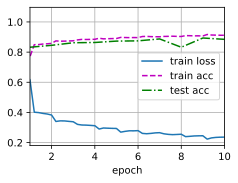

In [27]:
lr, num_epochs = 0.1, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 我的发现
1. 使用最大汇聚层替换平均汇聚层，以及使用relu作为激活函数可以加快收敛速度，但是最后收敛结果与原来并无二致。原代码10 epoch acc=0.8，优化后10 epoch acc=0.86，源代码 30 epoch acc = 0.86
2. relu相较于sigmoid计算速度更快
3. 显示不同输入（例如毛衣和外套）时，LeNet第一层和第二层的激活值。
4. 减小batch_size可以加快收敛速度并提高模型准确率

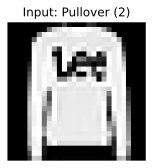

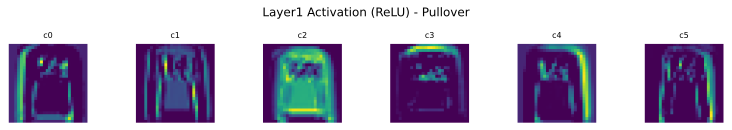

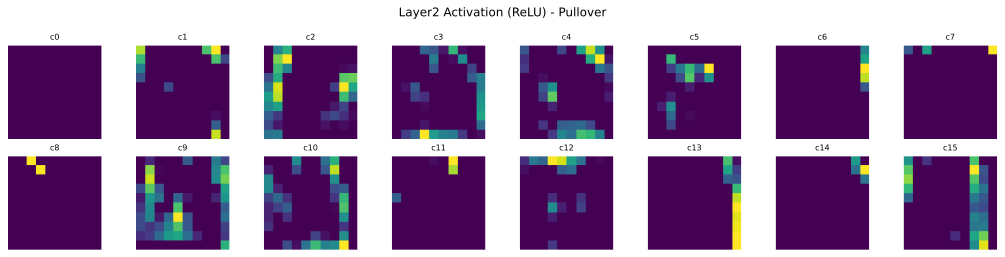

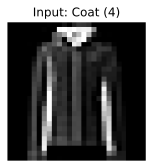

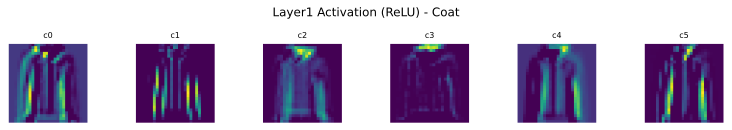

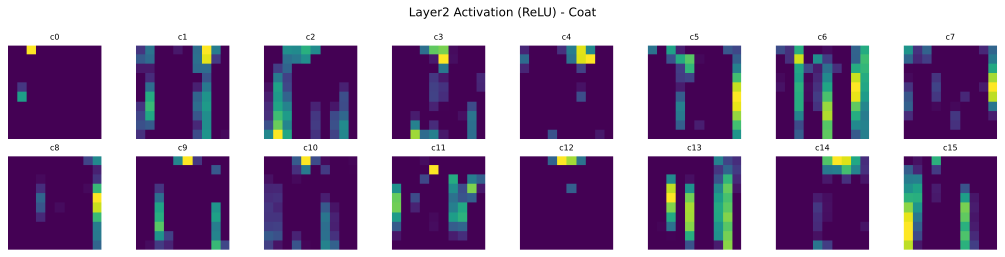

In [28]:
# ...existing code...
import torch
import matplotlib.pyplot as plt

# Fashion-MNIST 标签名
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def pick_one_by_label(data_iter, target_label):
    """从 data_iter 中取一张指定标签的图片，返回形状 [1,1,28,28]"""
    for X, y in data_iter:
        idx = (y == target_label).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            i = idx[0].item()
            return X[i:i+1], y[i].item()
    raise ValueError(f'未找到标签 {target_label} 的样本')

def get_first_two_layer_activations(net, x):
    """
    返回第一层和第二层卷积后的激活（ReLU后）
    LeNet: [0]Conv1 [1]ReLU [2]Pool [3]Conv2 [4]ReLU ...
    """
    with torch.no_grad():
        z1 = net[0](x)
        a1 = net[1](z1)        # 第一层激活
        p1 = net[2](a1)
        z2 = net[3](p1)
        a2 = net[4](z2)        # 第二层激活
    return a1.squeeze(0).cpu(), a2.squeeze(0).cpu()

def plot_feature_maps(feat, title, max_maps=16, ncols=8):
    n = min(feat.shape[0], max_maps)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8*ncols, 1.8*nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i in range(nrows * ncols):
        axes[i].axis('off')
        if i < n:
            axes[i].imshow(feat[i], cmap='viridis')
            axes[i].set_title(f'c{i}', fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

device = next(net.parameters()).device
net.eval()

# 例如：毛衣(Pullover=2) 和 外套(Coat=4)
for lbl in [2, 4]:
    x, y = pick_one_by_label(test_iter, lbl)
    x = x.to(device)

    a1, a2 = get_first_two_layer_activations(net, x)

    # 原图
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(x[0, 0].cpu(), cmap='gray')
    plt.title(f'Input: {label_names[y]} ({y})')
    plt.axis('off')
    plt.show()

    # 第一层和第二层激活图
    plot_feature_maps(a1, f'Layer1 Activation (ReLU) - {label_names[y]}', max_maps=6, ncols=6)
    plot_feature_maps(a2, f'Layer2 Activation (ReLU) - {label_names[y]}', max_maps=16, ncols=8)
# ...existing code...